# Dataset과 Dataloader

이 노트북은 `MNISTDataset`의 task별 target 변환과 `Dataloader`의 배치·shuffle 동작을 직접 실행하고 검증하는 실습 자료이다.
이전 노트북의 변수나 실행 결과를 사용하지 않으며, 이 노트북 단독으로 완전히 실행할 수 있다.

**실행 환경**: `conda run -n numpy_py311` (GPU 불필요)

**데이터셋 경로**: `/mnt/d/datasets/mnist/` (train/test `.gz` 4개 파일 필요)

**목표**
- `MNISTDataset`의 3가지 task(`multiclass`, `binary`, `regression`)별 target 배열의 shape와 값을 확인한다.
- `Dataloader`로 배치를 생성하고 `batch_size`, `shuffle`, `__len__` 동작을 검증한다.
- task별 target 시각화를 통해 변환 결과를 직관적으로 파악한다.

## 0. 환경 설정

In [1]:
# sys.path setup -- excluded from jupyter book build
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"project_root={PROJECT_ROOT}")

project_root=/mnt/d/projects/nampluskr/10_active/260615_mnist-numpy-from-scratch


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from src.data.mnist import MNISTDataset
from src.data.dataloader import Dataloader

## 1. 개요

`MNISTDataset`은 `load_mnist`로 읽은 원본 uint8 배열을 float32 정규화 이미지와 task별 target으로 변환하는 클래스이다.
`Dataloader`는 `__len__`과 `__getitem__`을 구현한 Dataset이면 종류에 관계없이 받아 mini-batch를 생성하는 범용 이터레이터이다.

두 클래스의 역할과 출력 형태는 다음과 같다.

| 클래스 | 역할 | 출력 |
|---|---|---|
| `MNISTDataset` | 정규화 + task별 target 변환 | `(image, target)` 단일 샘플 tuple |
| `Dataloader` | 배치 생성 + shuffle | `(images_batch, targets_batch)` tuple yield |

## 2. MNISTDataset — task별 target 변환

`MNISTDataset`은 `split`과 `task`를 받아 이미지를 `(N, 784)` float32로 reshape·정규화하고, task에 맞는 target을 생성한다.
`task`에 따른 target 변환 규칙은 다음과 같다.

| task | 변환 | target shape | 값 범위 |
|---|---|---|---|
| `multiclass` | one-hot encoding | `(N, 10)` | 0.0 또는 1.0 |
| `binary` | 홀수=1, 짝수=0 | `(N, 1)` | 0.0 또는 1.0 |
| `regression` | `label / 9.0` | `(N, 1)` | 0.0~1.0 |

In [4]:
tasks = ['multiclass', 'binary', 'regression']
datasets = {task: MNISTDataset('train', task) for task in tasks}

for task, ds in datasets.items():
    img, tgt = ds[0]
    print(f"[{task}]")
    print(f"  len={len(ds)}, images.shape={ds.images.shape}, images.dtype={ds.images.dtype}")
    print(f"  targets.shape={ds.targets.shape}, targets.dtype={ds.targets.dtype}")
    print(f"  sample[0]: image.shape={img.shape}, target.shape={tgt.shape}, target={tgt}")
    print()

[multiclass]
  len=60000, images.shape=(60000, 784), images.dtype=float32
  targets.shape=(60000, 10), targets.dtype=float32
  sample[0]: image.shape=(784,), target.shape=(10,), target=[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

[binary]
  len=60000, images.shape=(60000, 784), images.dtype=float32
  targets.shape=(60000, 1), targets.dtype=float32
  sample[0]: image.shape=(784,), target.shape=(1,), target=[1.]

[regression]
  len=60000, images.shape=(60000, 784), images.dtype=float32
  targets.shape=(60000, 1), targets.dtype=float32
  sample[0]: image.shape=(784,), target.shape=(1,), target=[0.5555556]



In [5]:
ds_mc = datasets['multiclass']
ds_bi = datasets['binary']
ds_rg = datasets['regression']

# image shape/dtype
assert ds_mc.images.shape == (60000, 784), f"got {ds_mc.images.shape}"
assert ds_mc.images.dtype == np.float32
assert ds_mc.images.min() >= 0.0 and ds_mc.images.max() <= 1.0, "image not normalized"

# target shapes
assert ds_mc.targets.shape == (60000, 10), f"multiclass target: {ds_mc.targets.shape}"
assert ds_bi.targets.shape == (60000, 1),  f"binary target: {ds_bi.targets.shape}"
assert ds_rg.targets.shape == (60000, 1),  f"regression target: {ds_rg.targets.shape}"

# multiclass: one-hot (exactly one 1.0 per row)
assert np.allclose(ds_mc.targets.sum(axis=1), 1.0), "multiclass row sum != 1"

# binary: only 0 or 1
assert set(np.unique(ds_bi.targets)).issubset({0.0, 1.0}), "binary has unexpected values"

# regression: range [0, 1]
assert ds_rg.targets.min() >= 0.0 and ds_rg.targets.max() <= 1.0, "regression out of range"

# __getitem__ returns tuple
img, tgt = ds_mc[0]
assert img.shape == (784,), f"__getitem__ image shape: {img.shape}"
assert tgt.shape == (10,), f"__getitem__ target shape: {tgt.shape}"

print("MNISTDataset validation passed")

MNISTDataset validation passed


## 3. task별 target 시각화

train 첫 10개 샘플에 대해 task별 target 값을 나란히 표시한다.
같은 레이블이 task에 따라 어떻게 다른 형태의 target으로 변환되는지 비교한다.

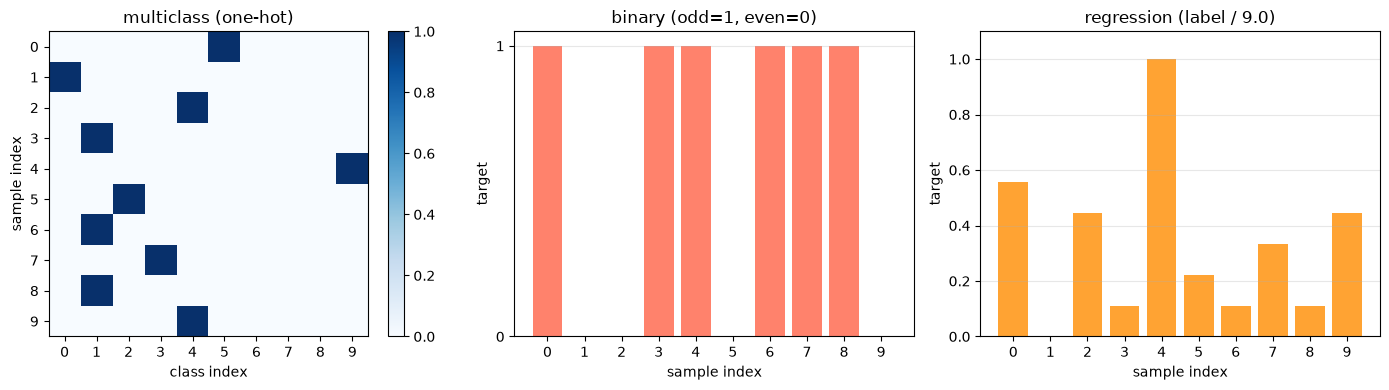

In [14]:
n_show = 10
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# multiclass one-hot heatmap
mc_targets = ds_mc.targets[:n_show]  # (10, 10)
im0 = axes[0].imshow(mc_targets, cmap='Blues', vmin=0, vmax=1, aspect='auto')
axes[0].set_title("multiclass (one-hot)")
axes[0].set_xlabel("class index")
axes[0].set_ylabel("sample index")
axes[0].set_xticks(range(10))
axes[0].set_yticks(range(n_show))
fig.colorbar(im0, ax=axes[0])

# binary bar chart
bi_targets = ds_bi.targets[:n_show, 0]  # (10,)
colors = ['tomato' if v == 1.0 else 'steelblue' for v in bi_targets]
axes[1].bar(range(n_show), bi_targets, color=colors, alpha=0.8)
axes[1].set_title("binary (odd=1, even=0)")
axes[1].set_xlabel("sample index")
axes[1].set_ylabel("target")
axes[1].set_xticks(range(n_show))
axes[1].set_yticks([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# regression scatter
rg_targets = ds_rg.targets[:n_show, 0]  # (10,)
axes[2].bar(range(n_show), rg_targets, color='darkorange', alpha=0.8)
axes[2].set_title("regression (label / 9.0)")
axes[2].set_xlabel("sample index")
axes[2].set_ylabel("target")
axes[2].set_xticks(range(n_show))
axes[2].set_ylim(0, 1.1)
axes[2].grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

## 4. Dataloader — 배치 생성

`Dataloader`는 Dataset을 받아 `batch_size` 단위로 이미지 배치와 target 배치를 yield한다.
`shuffle=True`이면 에폭마다 다른 순서로 배치를 생성하여 학습 다양성을 높인다.
`__len__`은 전체 배치 수를 반환하며, 마지막 배치는 남은 샘플 수가 `batch_size`보다 작을 수 있다.

In [7]:
BATCH_SIZE = 256
ds = MNISTDataset('train', 'multiclass')
loader = Dataloader(ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"dataset size: {len(ds)}")
print(f"batch_size: {BATCH_SIZE}")
print(f"len(loader): {len(loader)} batches")

# check first 3 batches
for i, (x, y) in enumerate(loader):
    print(f"  batch {i}: x.shape={x.shape}, y.shape={y.shape}")
    if i >= 2:
        print("  ...")
        break

# check last batch
batches = list(loader)
x_last, y_last = batches[-1]
print(f"  last batch: x.shape={x_last.shape}  (60000 mod 256 = {60000 % BATCH_SIZE} samples)")

dataset size: 60000
batch_size: 256
len(loader): 235 batches
  batch 0: x.shape=(256, 784), y.shape=(256, 10)
  batch 1: x.shape=(256, 784), y.shape=(256, 10)
  batch 2: x.shape=(256, 784), y.shape=(256, 10)
  ...
  last batch: x.shape=(96, 784)  (60000 mod 256 = 96 samples)


In [8]:
import math

N = len(ds)
expected_batches = math.ceil(N / BATCH_SIZE)

assert len(loader) == expected_batches, f"expected {expected_batches}, got {len(loader)}"
assert sum(len(x) for x, y in loader) == N, "total sample count mismatch"

# first batch shape
x0, y0 = next(iter(loader))
assert x0.shape == (BATCH_SIZE, 784), f"x batch shape: {x0.shape}"
assert y0.shape == (BATCH_SIZE, 10), f"y batch shape: {y0.shape}"

# last batch size
expected_last = N % BATCH_SIZE if N % BATCH_SIZE != 0 else BATCH_SIZE
assert len(x_last) == expected_last, f"last batch size: {len(x_last)}"

print("Dataloader shape/length validation passed")

Dataloader shape/length validation passed


## 5. shuffle 동작 확인

`shuffle=True`이면 에폭마다 다른 순서로 샘플을 반환한다.
같은 Dataloader를 두 번 순회할 때 첫 번째 배치의 이미지 순서가 다름을 확인한다.
또한 shuffle 여부와 관계없이 전체 샘플 수는 동일해야 한다.

In [9]:
loader_shuf = Dataloader(ds, batch_size=BATCH_SIZE, shuffle=True)

np.random.seed(0)
x_epoch1, _ = next(iter(loader_shuf))

np.random.seed(99)
x_epoch2, _ = next(iter(loader_shuf))

print(f"epoch1 first image[:5]: {x_epoch1[0, :5]}")
print(f"epoch2 first image[:5]: {x_epoch2[0, :5]}")
print(f"same order: {np.allclose(x_epoch1, x_epoch2)}")

epoch1 first image[:5]: [0. 0. 0. 0. 0.]
epoch2 first image[:5]: [0. 0. 0. 0. 0.]
same order: False


In [10]:
# shuffle=True: total sample count unchanged
assert sum(len(x) for x, y in loader_shuf) == N, "shuffle changed sample count"

# shuffle=True: order differs across epochs (with different seeds)
np.random.seed(0)
x_e1 = np.concatenate([x for x, _ in loader_shuf], axis=0)  # (N, 784)

np.random.seed(99)
x_e2 = np.concatenate([x for x, _ in loader_shuf], axis=0)  # (N, 784)

assert not np.allclose(x_e1, x_e2), "shuffle did not change order"

# shuffle=False: order is fixed
loader_fix = Dataloader(ds, batch_size=BATCH_SIZE, shuffle=False)
x_f1 = np.concatenate([x for x, _ in loader_fix], axis=0)
x_f2 = np.concatenate([x for x, _ in loader_fix], axis=0)
assert np.allclose(x_f1, x_f2), "non-shuffle changed order"

print("Dataloader shuffle validation passed")

Dataloader shuffle validation passed


## 6. 3종 task 통합 확인

3가지 task Dataset과 Dataloader를 각각 생성하고 첫 번째 배치의 shape를 한눈에 비교한다.
학습 루프에서 실제로 사용하는 방식과 동일하게 `for x, y in loader` 순회를 시연한다.

In [11]:
BATCH_SIZE = 128

for task in ['multiclass', 'binary', 'regression']:
    ds_task = MNISTDataset('train', task)
    loader_task = Dataloader(ds_task, batch_size=BATCH_SIZE, shuffle=True)
    x_batch, y_batch = next(iter(loader_task))
    print(f"[{task:12s}] x: {x_batch.shape}  y: {y_batch.shape}  "
          f"y.min={y_batch.min():.3f}  y.max={y_batch.max():.3f}")

[multiclass  ] x: (128, 784)  y: (128, 10)  y.min=0.000  y.max=1.000
[binary      ] x: (128, 784)  y: (128, 1)  y.min=0.000  y.max=1.000
[regression  ] x: (128, 784)  y: (128, 1)  y.min=0.000  y.max=1.000


In [12]:
expected_y_shapes = {
    'multiclass': (BATCH_SIZE, 10),
    'binary':     (BATCH_SIZE, 1),
    'regression': (BATCH_SIZE, 1),
}

for task, expected_shape in expected_y_shapes.items():
    ds_t = MNISTDataset('train', task)
    ld_t = Dataloader(ds_t, batch_size=BATCH_SIZE, shuffle=False)
    x, y = next(iter(ld_t))
    assert x.shape == (BATCH_SIZE, 784), f"{task} x shape: {x.shape}"
    assert y.shape == expected_shape, f"{task} y shape: {y.shape} != {expected_shape}"
    assert x.dtype == np.float32, f"{task} x dtype: {x.dtype}"
    assert y.dtype == np.float32, f"{task} y dtype: {y.dtype}"

print("3-task integration validation passed")

3-task integration validation passed


## 요약

이 노트북에서 확인한 내용은 다음과 같다.

| 클래스 | 핵심 확인 사항 |
|---|---|
| `MNISTDataset` | images `(N,784)` float32 정규화, task별 targets dtype/shape/값 범위 |
| `MNISTDataset.__getitem__` | `(image, target)` tuple 단일 샘플 반환 |
| `Dataloader.__len__` | `ceil(N / batch_size)` 배치 수 반환 |
| `Dataloader` 순회 | `(x_batch, y_batch)` tuple yield, 마지막 배치 가변 크기 |
| `shuffle=True` | 에폭마다 다른 순서, 전체 샘플 수는 동일 |

**핵심 설계 원칙**
- `MNISTDataset`은 정규화와 target 변환을 내부에서 처리하므로, 클라이언트 코드는 task 이름만 지정하면 된다.
- `Dataloader`는 `__len__`과 `__getitem__`을 구현한 Dataset이면 종류에 관계없이 받아 동작한다.
- `for x, y in loader` 한 줄로 mini-batch 학습 루프를 구성할 수 있다.